# **Robust SQL Injection Detection via Weighted Ensemble of CNN, BiLSTM, Random Forest and SVM**
## Cross-validated | Adversarially Tested | Hyperparameter-Tuned
**Dataset:** SQL Injection Dataset (Kaggle)  
**Models:** CNN · BiLSTM · Random Forest · SVM → Majority-Vote Ensemble  
**Extras:** K-Fold CV · Adversarial Robustness · ROC/PR Curves · Grad-CAM Attribution

In [2]:
# installing lightweight hyperparameter tuner
!pip install -q keras-tuner optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 40.3 MB/s eta 0:00:00


In [3]:
import os, re, json, pickle, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, mixed_precision

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Enable mixed-precision for T4 GPU speed
mixed_precision.set_global_policy("mixed_float16")

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TF version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TF version: 2.19.0
GPU available: True


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
class Config:
    DATA_PATH       = "/content/drive/My Drive/Datasets"
    QUERY_COL       = "Query"
    LABEL_COL       = "Label"
    TEST_SIZE       = 0.15
    N_FOLDS         = 5
    BATCH_SIZE      = 128
    EPOCHS_TUNING   = 8
    EPOCHS_FINAL    = 25
    PATIENCE        = 4
    TFIDF_FEATURES  = 8000
    TFIDF_NGRAMS    = (1, 3)
    RF_TREES        = 200
    OPTUNA_TRIALS   = 20
    SAVE_DIR        = "/content/drive/My Drive/MLProject/SQL_Injection/saved_models"

os.makedirs(Config.SAVE_DIR, exist_ok=True)
cfg = Config()

Total samples  : 30846
Class balance  :
Label
0    19524
1    11322
Name: count, dtype: int64

Duplicate queries removed. Clean shape: (30846, 2)

Token length stats → mean=12.4, p95=41, p99=79, max=216


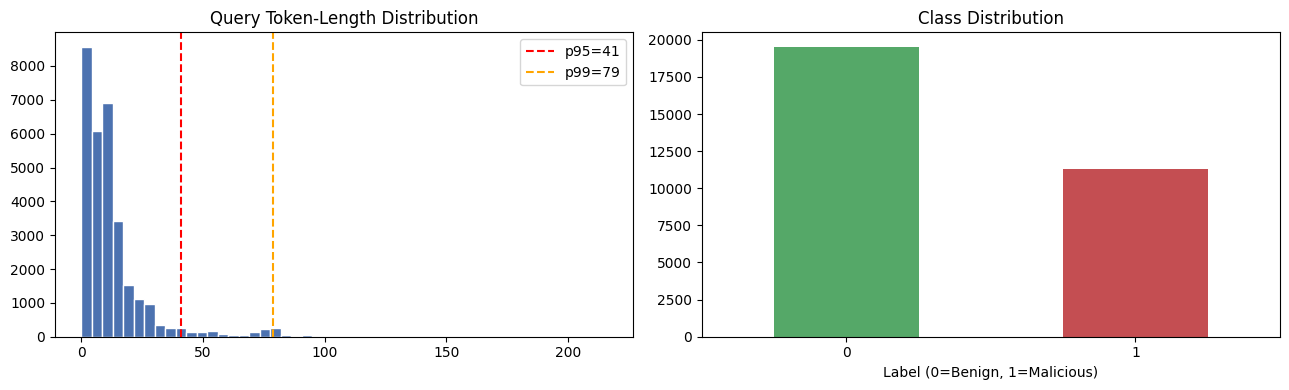


Data-driven VOCAB_SIZE = 10000  (covers ≥99% token occurrences)
Data-driven MAX_SEQ_LEN = 41 (p95 of query lengths)


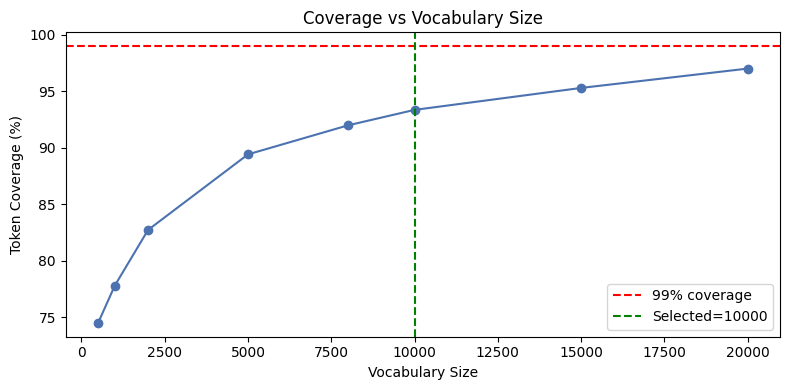

In [12]:

cfg.DATA_PATH = os.path.join(cfg.DATA_PATH, "sql_injection_dataset.csv")
df = pd.read_csv(cfg.DATA_PATH)
df = df[[cfg.QUERY_COL, cfg.LABEL_COL]].dropna()
df[cfg.QUERY_COL] = df[cfg.QUERY_COL].astype(str).str.strip()
df = df.drop_duplicates(subset=cfg.QUERY_COL)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Total samples  : {len(df)}")
print(f"Class balance  :\n{df[cfg.LABEL_COL].value_counts()}")
print(f"\nDuplicate queries removed. Clean shape: {df.shape}")

# Query length distribution — justifies max_sequence_length
query_lengths = df[cfg.QUERY_COL].apply(str.split).apply(len)
p95 = int(np.percentile(query_lengths, 95))
p99 = int(np.percentile(query_lengths, 99))
print(f"\nToken length stats → mean={query_lengths.mean():.1f}, "
      f"p95={p95}, p99={p99}, max={query_lengths.max()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(query_lengths, bins=50, color="#4C72B0", edgecolor="white")
axes[0].axvline(p95, color="red", linestyle="--", label=f"p95={p95}")
axes[0].axvline(p99, color="orange", linestyle="--", label=f"p99={p99}")
axes[0].set_title("Query Token-Length Distribution"); axes[0].legend()

df[cfg.LABEL_COL].value_counts().plot.bar(ax=axes[1], color=["#55A868","#C44E52"],
                                           rot=0)
axes[1].set_title("Class Distribution")
axes[1].set_xlabel("Label (0=Benign, 1=Malicious)")
plt.tight_layout(); plt.show()

# ── Justify vocab_size ──────────────────────────────────────────────────────
from collections import Counter
from tensorflow.keras.preprocessing.text import Tokenizer as _Tok

_tmp = _Tok()
_tmp.fit_on_texts(df[cfg.QUERY_COL])
vocab_sizes = [500, 1000, 2000, 5000, 8000, 10000, 15000, 20000]
coverage = []
total_tokens = sum(_tmp.word_counts.values())
sorted_counts = sorted(_tmp.word_counts.values(), reverse=True)
cumsum = np.cumsum(sorted_counts)
for vs in vocab_sizes:
    cov = cumsum[min(vs-1, len(cumsum)-1)] / total_tokens
    coverage.append(cov * 100)

# Data-driven vocab selection: smallest size that achieves >= 99% coverage
VOCAB_SIZE = next((vs for vs, cov in zip(vocab_sizes, coverage) if cov >= 99.0),
                  10000)
MAX_SEQ_LEN = p95  # cover 95% of queries without padding waste

print(f"\nData-driven VOCAB_SIZE = {VOCAB_SIZE}  "
      f"(covers ≥99% token occurrences)")
print(f"Data-driven MAX_SEQ_LEN = {MAX_SEQ_LEN} (p95 of query lengths)")

plt.figure(figsize=(8, 4))
plt.plot(vocab_sizes, coverage, "o-", color="#4C72B0")
plt.axhline(99, color="red", linestyle="--", label="99% coverage")
plt.axvline(VOCAB_SIZE, color="green", linestyle="--",
            label=f"Selected={VOCAB_SIZE}")
plt.xlabel("Vocabulary Size"); plt.ylabel("Token Coverage (%)")
plt.title("Coverage vs Vocabulary Size"); plt.legend(); plt.tight_layout()
plt.show()

In [13]:
# Preprocessing Pipeline
class SQLPreprocessor:
    """Handles both tokenizer-based (DL) and TF-IDF-based (ML) preprocessing."""

    def __init__(self, vocab_size: int, max_seq_len: int,
                 tfidf_features: int, tfidf_ngrams: tuple):
        self.vocab_size    = vocab_size
        self.max_seq_len   = max_seq_len
        self.tfidf_features = tfidf_features
        self.tfidf_ngrams  = tfidf_ngrams

        from tensorflow.keras.preprocessing.text import Tokenizer as _Tok
        self._tok = _Tok(num_words=vocab_size, oov_token="<OOV>",
                         lower=True, filters='')
        self._tfidf = TfidfVectorizer(max_features=tfidf_features,
                                      ngram_range=tfidf_ngrams,
                                      analyzer="char_wb",
                                      sublinear_tf=True)
        self.fitted = False

    def fit(self, texts):
        """Fit both tokenizer and TF-IDF on training texts only."""
        self._tok.fit_on_texts(texts)
        self._tfidf.fit(texts)
        self.fitted = True
        return self

    def transform_dl(self, texts):
        from tensorflow.keras.preprocessing.sequence import pad_sequences
        seqs = self._tok.texts_to_sequences(texts)
        return pad_sequences(seqs, maxlen=self.max_seq_len,
                             padding="post", truncating="post")

    def transform_ml(self, texts):
        return self._tfidf.transform(texts)

    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump(self, f)

    @staticmethod
    def load(path: str):
        with open(path, "rb") as f:
            return pickle.load(f)


preprocessor = SQLPreprocessor(
    vocab_size    = VOCAB_SIZE,
    max_seq_len   = MAX_SEQ_LEN,
    tfidf_features= cfg.TFIDF_FEATURES,
    tfidf_ngrams  = cfg.TFIDF_NGRAMS
)
print("SQLPreprocessor created — char_wb TF-IDF + token-based DL preprocessing.")

SQLPreprocessor created — char_wb TF-IDF + token-based DL preprocessing.


In [14]:
# stratified Split: 85% train+val | 15% held-out test
X_all = df[cfg.QUERY_COL].values
y_all = df[cfg.LABEL_COL].values.astype(np.int32)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_all, y_all,
    test_size=cfg.TEST_SIZE,
    random_state=SEED,
    stratify=y_all
)

# fit preprocessor on development set ONLY (no test leakage)
preprocessor.fit(X_dev)
preprocessor.save(os.path.join(cfg.SAVE_DIR, "preprocessor.pkl"))

X_test_dl = preprocessor.transform_dl(X_test)
X_test_ml = preprocessor.transform_ml(X_test)

print(f"Dev set : {len(X_dev):,} | Test set : {len(X_test):,}")
print(f"Test class balance → "
      f"{Counter(y_test)}")

Dev set : 26,219 | Test set : 4,627
Test class balance → Counter({np.int32(0): 2929, np.int32(1): 1698})


In [15]:
# deep Learning model factory
def build_cnn(vocab_size: int, seq_len: int,
              emb_dim: int = 128, filters1: int = 128,
              filters2: int = 256, kernel: int = 3,
              dropout: float = 0.4) -> keras.Model:
    """Two-block CNN with residual-style feature concatenation."""
    inp = layers.Input(shape=(seq_len,))
    x   = layers.Embedding(vocab_size, emb_dim, mask_zero=False)(inp)

    # Block 1
    c1  = layers.Conv1D(filters1, kernel, padding="same", activation="relu")(x)
    c1  = layers.BatchNormalization()(c1)
    p1  = layers.GlobalMaxPooling1D()(c1)

    # Block 2
    c2  = layers.Conv1D(filters2, 5, padding="same", activation="relu")(x)
    c2  = layers.BatchNormalization()(c2)
    p2  = layers.GlobalMaxPooling1D()(c2)

    cat = layers.Concatenate()([p1, p2])
    cat = layers.Dropout(dropout)(cat)
    out = layers.Dense(64, activation="relu")(cat)
    out = layers.Dropout(dropout / 2)(out)
    out = layers.Dense(1, activation="sigmoid",
                       dtype="float32", name="output")(out)
    return keras.Model(inp, out, name="CNN")


def build_bilstm(vocab_size: int, seq_len: int,
                 emb_dim: int = 128, units1: int = 128,
                 units2: int = 64, dropout: float = 0.4) -> keras.Model:
    """Stacked Bidirectional LSTM with attention pooling."""
    inp = layers.Input(shape=(seq_len,))
    x   = layers.Embedding(vocab_size, emb_dim, mask_zero=True)(inp)
    x   = layers.Bidirectional(
              layers.LSTM(units1, return_sequences=True,
                          dropout=dropout, recurrent_dropout=0.1))(x)
    x   = layers.Bidirectional(
              layers.LSTM(units2, return_sequences=True,
                          dropout=dropout, recurrent_dropout=0.1))(x)
    # Self-attention pool
    att = layers.Dense(1, activation="tanh")(x)
    att = layers.Flatten()(att)
    att = layers.Activation("softmax")(att)
    att = layers.RepeatVector(units2 * 2)(att)
    att = layers.Permute([2, 1])(att)
    ctx = layers.Multiply()([x, att])
    ctx = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(ctx)
    out = layers.Dense(64, activation="relu")(ctx)
    out = layers.Dropout(dropout)(out)
    out = layers.Dense(1, activation="sigmoid",
                       dtype="float32", name="output")(out)
    return keras.Model(inp, out, name="BiLSTM")


def get_callbacks(monitor="val_auc", patience=cfg.PATIENCE,
                  model_name="model") -> list:
    ckpt_path = os.path.join(cfg.SAVE_DIR, f"{model_name}_best.h5")
    return [
        callbacks.EarlyStopping(monitor=monitor, patience=patience,
                                restore_best_weights=True,
                                mode="max", verbose=0),
        callbacks.ReduceLROnPlateau(monitor=monitor, factor=0.5,
                                    patience=patience // 2,
                                    min_lr=1e-6, verbose=0),
        callbacks.ModelCheckpoint(ckpt_path, monitor=monitor,
                                  save_best_only=True, verbose=0)
    ]

print("Model factory ready — CNN & BiLSTM builders defined.")

Model factory ready — CNN & BiLSTM builders defined.


In [16]:
# Hyperparameter Tuning with Optuna (CNN)
# 20 lightweight trials on a fast validation split, no leakage

X_ht_train, X_ht_val, y_ht_train, y_ht_val = train_test_split(
    X_dev, y_dev, test_size=0.2, random_state=SEED, stratify=y_dev
)
X_ht_train_dl = preprocessor.transform_dl(X_ht_train)
X_ht_val_dl   = preprocessor.transform_dl(X_ht_val)


def objective_cnn(trial):
    emb_dim  = trial.suggest_categorical("emb_dim",  [64, 128, 256])
    filters1 = trial.suggest_categorical("filters1", [64, 128, 256])
    filters2 = trial.suggest_categorical("filters2", [128, 256, 512])
    kernel   = trial.suggest_categorical("kernel",   [3, 5, 7])
    dropout  = trial.suggest_float("dropout", 0.2, 0.5, step=0.1)
    lr       = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    m = build_cnn(VOCAB_SIZE, MAX_SEQ_LEN, emb_dim, filters1,
                  filters2, kernel, dropout)
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])

    hist = m.fit(X_ht_train_dl, y_ht_train,
                 validation_data=(X_ht_val_dl, y_ht_val),
                 epochs=cfg.EPOCHS_TUNING,
                 batch_size=cfg.BATCH_SIZE,
                 callbacks=[callbacks.EarlyStopping(
                     monitor="val_auc", patience=3, mode="max",
                     restore_best_weights=True)],
                 verbose=0)
    return max(hist.history["val_auc"])


study_cnn = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_cnn.optimize(objective_cnn, n_trials=cfg.OPTUNA_TRIALS)

best_cnn_params = study_cnn.best_params
print("\nBest CNN params:", best_cnn_params)
print(f"Best CNN val-AUC: {study_cnn.best_value:.4f}")


Best CNN params: {'emb_dim': 128, 'filters1': 64, 'filters2': 128, 'kernel': 3, 'dropout': 0.30000000000000004, 'lr': 0.0002101079931010357}
Best CNN val-AUC: 0.9982


In [17]:
# Stratified K-Fold Cross-Validation
# Validates both DL and ML models with statistical rigor

skf = StratifiedKFold(n_splits=cfg.N_FOLDS, shuffle=True, random_state=SEED)

fold_results = {m: [] for m in ["CNN", "BiLSTM", "RF", "SVM"]}
oof_preds    = {m: np.zeros(len(X_dev)) for m in fold_results}

for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_dev, y_dev)):
    print(f"\n{'='*55}")
    print(f"FOLD {fold_idx + 1}/{cfg.N_FOLDS}")
    print(f"{'='*55}")

    X_tr_raw, X_va_raw = X_dev[tr_idx], X_dev[va_idx]
    y_tr, y_va         = y_dev[tr_idx], y_dev[va_idx]

    # Fresh preprocessor per fold, no leakage
    fold_prep = SQLPreprocessor(VOCAB_SIZE, MAX_SEQ_LEN,
                                cfg.TFIDF_FEATURES, cfg.TFIDF_NGRAMS)
    fold_prep.fit(X_tr_raw)

    X_tr_dl = fold_prep.transform_dl(X_tr_raw)
    X_va_dl = fold_prep.transform_dl(X_va_raw)
    X_tr_ml = fold_prep.transform_ml(X_tr_raw)
    X_va_ml = fold_prep.transform_ml(X_va_raw)

    # CNN
    cnn = build_cnn(VOCAB_SIZE, MAX_SEQ_LEN, **{
        k: best_cnn_params[k]
        for k in ["emb_dim","filters1","filters2","kernel","dropout"]
    })
    cnn.compile(optimizer=keras.optimizers.Adam(best_cnn_params["lr"]),
                loss="binary_crossentropy",
                metrics=[keras.metrics.AUC(name="auc")])
    cnn.fit(X_tr_dl, y_tr, validation_data=(X_va_dl, y_va),
            epochs=cfg.EPOCHS_FINAL, batch_size=cfg.BATCH_SIZE,
            callbacks=get_callbacks("val_auc", cfg.PATIENCE, f"cnn_f{fold_idx}"),
            verbose=1)
    cnn_prob = cnn.predict(X_va_dl, verbose=0).flatten()
    cnn_auc  = roc_auc_score(y_va, cnn_prob)
    fold_results["CNN"].append(cnn_auc)
    oof_preds["CNN"][va_idx] = cnn_prob
    print(f"CNN    AUC: {cnn_auc:.4f}")

    # BiLSTM
    bilstm = build_bilstm(VOCAB_SIZE, MAX_SEQ_LEN)
    bilstm.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss="binary_crossentropy",
                   metrics=[keras.metrics.AUC(name="auc")])
    bilstm.fit(X_tr_dl, y_tr, validation_data=(X_va_dl, y_va),
               epochs=cfg.EPOCHS_FINAL, batch_size=cfg.BATCH_SIZE,
               callbacks=get_callbacks("val_auc", cfg.PATIENCE, f"bilstm_f{fold_idx}"),
               verbose=1)
    bilstm_prob = bilstm.predict(X_va_dl, verbose=0).flatten()
    bilstm_auc  = roc_auc_score(y_va, bilstm_prob)
    fold_results["BiLSTM"].append(bilstm_auc)
    oof_preds["BiLSTM"][va_idx] = bilstm_prob
    print(f"BiLSTM AUC: {bilstm_auc:.4f}")

    # Random Forest
    rf = RandomForestClassifier(n_estimators=cfg.RF_TREES,
                                class_weight="balanced",
                                random_state=SEED, n_jobs=-1)
    rf.fit(X_tr_ml, y_tr)
    rf_prob = rf.predict_proba(X_va_ml)[:, 1]
    rf_auc  = roc_auc_score(y_va, rf_prob)
    fold_results["RF"].append(rf_auc)
    oof_preds["RF"][va_idx] = rf_prob
    print(f"RF     AUC: {rf_auc:.4f}")

    # SVM (Linear, calibrated)
    svm = CalibratedClassifierCV(LinearSVC(max_iter=3000, random_state=SEED), cv=3)
    svm.fit(X_tr_ml, y_tr)
    svm_prob = svm.predict_proba(X_va_ml)[:, 1]
    svm_auc  = roc_auc_score(y_va, svm_prob)
    fold_results["SVM"].append(svm_auc)
    oof_preds["SVM"][va_idx] = svm_prob
    print(f"SVM    AUC: {svm_auc:.4f}")


# summary
print("\n" + "="*55)
print("CROSS-VALIDATION SUMMARY")
print("="*55)
for model_name, aucs in fold_results.items():
    arr = np.array(aucs)
    print(f"{model_name:8s}  AUC = {arr.mean():.4f} ± {arr.std():.4f}")


FOLD 1/5
Epoch 1/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - auc: 0.9417 - loss: 0.2489

164/164 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - auc: 0.9419 - loss: 0.2482 - val_auc: 0.9987 - val_loss: 0.4577 - learning_rate: 2.1011e-04
Epoch 2/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9979 - loss: 0.0298 - val_auc: 0.9990 - val_loss: 0.2293 - learning_rate: 2.1011e-04
Epoch 3/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9985 - loss: 0.0196 - val_auc: 0.9990 - val_loss: 0.0632 - learning_rate: 2.1011e-04
Epoch 4/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9985 - loss: 0.0160 - val_auc: 0.9991 - val_loss: 0.0207 - learning_rate: 1.0505e-04
Epoch 5/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9986 - loss: 0.0151 - val_auc: 0.9989 - val_loss: 0.0143 - learning_rate: 1.0505e-04
Epoch 6/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9985 - loss: 0.0132 - val_auc: 0.9990 - val_loss: 0.0138 - learning_rate: 5.2527e-05
Epoch 7/25
158/164 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9987 - loss: 0.0127

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9987 - loss: 0.0128 - val_auc: 0.9987 - val_loss: 0.0140 - learning_rate: 5.2527e-05
Epoch 8/25
152/164 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9988 - loss: 0.0119

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9988 - loss: 0.0120 - val_auc: 0.9984 - val_loss: 0.0140 - learning_rate: 2.6263e-05
CNN    AUC: 0.9991
Epoch 1/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - auc: 0.8967 - loss: 0.3364

164/164 ━━━━━━━━━━━━━━━━━━━━ 144s 745ms/step - auc: 0.8972 - loss: 0.3354 - val_auc: 0.9962 - val_loss: 0.0341 - learning_rate: 0.0010
Epoch 2/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 137s 752ms/step - auc: 0.9949 - loss: 0.0372 - val_auc: 0.9967 - val_loss: 0.0234 - learning_rate: 0.0010
Epoch 3/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 126s 768ms/step - auc: 0.9959 - loss: 0.0287 - val_auc: 0.9965 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 4/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 116s 705ms/step - auc: 0.9969 - loss: 0.0248 - val_auc: 0.9984 - val_loss: 0.0175 - learning_rate: 5.0000e-04
Epoch 5/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 122s 744ms/step - auc: 0.9969 - loss: 0.0229 - val_auc: 0.9984 - val_loss: 0.0172 - learning_rate: 5.0000e-04
Epoch 6/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 116s 708ms/step - auc: 0.9979 - loss: 0.0202 - val_auc: 0.9983 - val_loss: 0.0177 - learning_rate: 2.5000e-04
Epoch 7/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 143s 715ms/step - auc: 0.9978 - loss: 0.0199 - val_auc: 0.9983 - val_loss: 0.0181 -

...

164/164 ━━━━━━━━━━━━━━━━━━━━ 136s 730ms/step - auc: 0.9166 - loss: 0.2912 - val_auc: 0.9932 - val_loss: 0.0441 - learning_rate: 0.0010
Epoch 2/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 117s 714ms/step - auc: 0.9951 - loss: 0.0349 - val_auc: 0.9963 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 3/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 705ms/step - auc: 0.9956 - loss: 0.0291 - val_auc: 0.9968 - val_loss: 0.0394 - learning_rate: 0.0010
Epoch 4/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 704ms/step - auc: 0.9965 - loss: 0.0230 - val_auc: 0.9971 - val_loss: 0.0331 - learning_rate: 5.0000e-04
Epoch 5/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 117s 713ms/step - auc: 0.9969 - loss: 0.0204 - val_auc: 0.9975 - val_loss: 0.0329 - learning_rate: 5.0000e-04
Epoch 6/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 118s 717ms/step - auc: 0.9973 - loss: 0.0189 - val_auc: 0.9971 - val_loss: 0.0325 - learning_rate: 2.5000e-04
Epoch 7/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 140s 707ms/step - auc: 0.9977 - loss: 0.0189 - val_auc: 0.9973 - val_loss: 0.0325 -

164/164 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - auc: 0.9137 - loss: 0.3151 - val_auc: 0.9975 - val_loss: 0.4716 - learning_rate: 2.1011e-04
Epoch 2/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9974 - loss: 0.0381 - val_auc: 0.9985 - val_loss: 0.2445 - learning_rate: 2.1011e-04
Epoch 3/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9983 - loss: 0.0236 - val_auc: 0.9987 - val_loss: 0.0673 - learning_rate: 2.1011e-04
Epoch 4/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9981 - loss: 0.0188 - val_auc: 0.9989 - val_loss: 0.0224 - learning_rate: 1.0505e-04
Epoch 5/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9984 - loss: 0.0178 - val_auc: 0.9989 - val_loss: 0.0171 - learning_rate: 1.0505e-04
Epoch 6/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9986 - loss: 0.0150 - val_auc: 0.9989 - val_loss: 0.0166 - learning_rate: 5.2527e-05
Epoch 7/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9983 - loss: 0.0148 - val_auc: 0.9990 - val_loss: 0.0165 - learning_rate

164/164 ━━━━━━━━━━━━━━━━━━━━ 136s 733ms/step - auc: 0.8943 - loss: 0.3455 - val_auc: 0.9950 - val_loss: 0.0328 - learning_rate: 0.0010
Epoch 2/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 120s 734ms/step - auc: 0.9944 - loss: 0.0359 - val_auc: 0.9951 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 3/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 729ms/step - auc: 0.9957 - loss: 0.0289 - val_auc: 0.9971 - val_loss: 0.0247 - learning_rate: 0.0010
Epoch 4/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 139s 713ms/step - auc: 0.9971 - loss: 0.0238 - val_auc: 0.9981 - val_loss: 0.0226 - learning_rate: 5.0000e-04
Epoch 5/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 127s 773ms/step - auc: 0.9971 - loss: 0.0222 - val_auc: 0.9980 - val_loss: 0.0218 - learning_rate: 5.0000e-04
Epoch 6/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 126s 771ms/step - auc: 0.9979 - loss: 0.0196 - val_auc: 0.9980 - val_loss: 0.0209 - learning_rate: 2.5000e-04
Epoch 7/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 124s 758ms/step - auc: 0.9975 - loss: 0.0197 - val_auc: 0.9983 - val_loss: 0.0214 -

164/164 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - auc: 0.8872 - loss: 0.3456 - val_auc: 0.9981 - val_loss: 0.4645 - learning_rate: 2.1011e-04
Epoch 2/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9978 - loss: 0.0342 - val_auc: 0.9987 - val_loss: 0.2333 - learning_rate: 2.1011e-04
Epoch 3/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9984 - loss: 0.0234 - val_auc: 0.9988 - val_loss: 0.0682 - learning_rate: 2.1011e-04
Epoch 4/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9987 - loss: 0.0181 - val_auc: 0.9989 - val_loss: 0.0210 - learning_rate: 1.0505e-04
Epoch 5/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9983 - loss: 0.0182 - val_auc: 0.9990 - val_loss: 0.0156 - learning_rate: 1.0505e-04
Epoch 6/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9983 - loss: 0.0167 - val_auc: 0.9989 - val_loss: 0.0151 - learning_rate: 5.2527e-05
Epoch 7/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9985 - loss: 0.0154 - val_auc: 0.9990 - val_loss: 0.0151 - learning_rate

164/164 ━━━━━━━━━━━━━━━━━━━━ 142s 756ms/step - auc: 0.9194 - loss: 0.2918 - val_auc: 0.9953 - val_loss: 0.0357 - learning_rate: 0.0010
Epoch 2/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 120s 731ms/step - auc: 0.9946 - loss: 0.0379 - val_auc: 0.9969 - val_loss: 0.0269 - learning_rate: 0.0010
Epoch 3/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 122s 744ms/step - auc: 0.9959 - loss: 0.0304 - val_auc: 0.9982 - val_loss: 0.0274 - learning_rate: 0.0010
Epoch 4/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 120s 731ms/step - auc: 0.9967 - loss: 0.0249 - val_auc: 0.9984 - val_loss: 0.0215 - learning_rate: 5.0000e-04
Epoch 5/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 143s 735ms/step - auc: 0.9970 - loss: 0.0231 - val_auc: 0.9983 - val_loss: 0.0271 - learning_rate: 5.0000e-04
Epoch 6/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 726ms/step - auc: 0.9981 - loss: 0.0203 - val_auc: 0.9983 - val_loss: 0.0226 - learning_rate: 2.5000e-04
Epoch 7/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 143s 733ms/step - auc: 0.9984 - loss: 0.0191 - val_auc: 0.9982 - val_loss: 0.0242 -

In [18]:

# trainin final models on full dev set and evaluate on held out test
X_dev_dl = preprocessor.transform_dl(X_dev)
X_dev_ml = preprocessor.transform_ml(X_dev)

# CNN (best params)
print("Training final CNN...")
final_cnn = build_cnn(VOCAB_SIZE, MAX_SEQ_LEN, **{
    k: best_cnn_params[k]
    for k in ["emb_dim","filters1","filters2","kernel","dropout"]
})
final_cnn.compile(
    optimizer=keras.optimizers.Adam(best_cnn_params["lr"]),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")]
)
final_cnn.fit(X_dev_dl, y_dev,
              validation_split=0.1,
              epochs=cfg.EPOCHS_FINAL,
              batch_size=cfg.BATCH_SIZE,
              callbacks=get_callbacks("val_auc", cfg.PATIENCE, "final_cnn"),
              verbose=1)

# BiLSTM
print("\nTraining final BiLSTM...")
final_bilstm = build_bilstm(VOCAB_SIZE, MAX_SEQ_LEN)
final_bilstm.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")]
)
final_bilstm.fit(X_dev_dl, y_dev,
                 validation_split=0.1,
                 epochs=cfg.EPOCHS_FINAL,
                 batch_size=cfg.BATCH_SIZE,
                 callbacks=get_callbacks("val_auc", cfg.PATIENCE, "final_bilstm"),
                 verbose=1)

# RF
print("\nTraining final RF...")
final_rf = RandomForestClassifier(n_estimators=cfg.RF_TREES,
                                  class_weight="balanced",
                                  random_state=SEED, n_jobs=-1)
final_rf.fit(X_dev_ml, y_dev)

# SVM
print("\nTraining final SVM...")
final_svm = CalibratedClassifierCV(LinearSVC(max_iter=3000, random_state=SEED), cv=3)
final_svm.fit(X_dev_ml, y_dev)

print("\nAll final models trained.")

Training final CNN...
Epoch 1/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - auc: 0.9438 - loss: 0.2410

185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - auc: 0.9440 - loss: 0.2403 - val_auc: 0.9988 - val_loss: 0.4192 - learning_rate: 2.1011e-04
Epoch 2/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9980 - loss: 0.0280 - val_auc: 0.9989 - val_loss: 0.1600 - learning_rate: 2.1011e-04
Epoch 3/25
172/185 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9984 - loss: 0.0186

185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9984 - loss: 0.0187 - val_auc: 0.9987 - val_loss: 0.0355 - learning_rate: 2.1011e-04
Epoch 4/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9986 - loss: 0.0150 - val_auc: 0.9989 - val_loss: 0.0175 - learning_rate: 1.0505e-04
Epoch 5/25
182/185 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9985 - loss: 0.0136

185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9985 - loss: 0.0136 - val_auc: 0.9973 - val_loss: 0.0175 - learning_rate: 1.0505e-04
Epoch 6/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9985 - loss: 0.0130 - val_auc: 0.9973 - val_loss: 0.0177 - learning_rate: 1.0505e-04

Training final BiLSTM...
Epoch 1/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - auc: 0.9230 - loss: 0.2838

185/185 ━━━━━━━━━━━━━━━━━━━━ 147s 717ms/step - auc: 0.9234 - loss: 0.2830 - val_auc: 0.9951 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 2/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 129s 697ms/step - auc: 0.9945 - loss: 0.0356 - val_auc: 0.9969 - val_loss: 0.0229 - learning_rate: 0.0010
Epoch 3/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 129s 696ms/step - auc: 0.9965 - loss: 0.0259 - val_auc: 0.9978 - val_loss: 0.0273 - learning_rate: 0.0010
Epoch 4/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 129s 697ms/step - auc: 0.9978 - loss: 0.0203 - val_auc: 0.9985 - val_loss: 0.0190 - learning_rate: 5.0000e-04
Epoch 5/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 132s 713ms/step - auc: 0.9984 - loss: 0.0182 - val_auc: 0.9986 - val_loss: 0.0190 - learning_rate: 5.0000e-04
Epoch 6/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 129s 696ms/step - auc: 0.9985 - loss: 0.0169 - val_auc: 0.9982 - val_loss: 0.0220 - learning_rate: 2.5000e-04
Epoch 7/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - auc: 0.9987 - loss: 0.0163 - val_auc: 0.9984 - val_loss: 0.0184 - le

In [19]:
# Weighted Soft-Vote Ensemble
# Weights derived from OOF (out-of-fold) AUC scores

oof_weights = {m: np.mean(aucs) for m, aucs in fold_results.items()}
total_w = sum(oof_weights.values())
oof_weights = {m: w / total_w for m, w in oof_weights.items()}
print("Ensemble weights:", {m: f"{w:.3f}" for m, w in oof_weights.items()})

def ensemble_predict(X_dl, X_ml, threshold=0.5):
    p_cnn    = final_cnn.predict(X_dl, verbose=0).flatten()
    p_bilstm = final_bilstm.predict(X_dl, verbose=0).flatten()
    p_rf     = final_rf.predict_proba(X_ml)[:, 1]
    p_svm    = final_svm.predict_proba(X_ml)[:, 1]

    prob = (oof_weights["CNN"]    * p_cnn   +
            oof_weights["BiLSTM"] * p_bilstm +
            oof_weights["RF"]     * p_rf     +
            oof_weights["SVM"]    * p_svm)
    return prob, (prob >= threshold).astype(int)

prob_test, pred_test = ensemble_predict(X_test_dl, X_test_ml)

print("\nEnsemble (Weighted Soft-Vote) — Held-Out Test Set")
print("="*55)
print(classification_report(y_test, pred_test,
      target_names=["Benign", "SQL Injection"],
      digits=4))
print(f"ROC-AUC  : {roc_auc_score(y_test, prob_test):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, prob_test):.4f}")

Ensemble weights: {'CNN': '0.250', 'BiLSTM': '0.250', 'RF': '0.250', 'SVM': '0.250'}

Ensemble (Weighted Soft-Vote) — Held-Out Test Set
               precision    recall  f1-score   support

       Benign     0.9946    1.0000    0.9973      2929
SQL Injection     1.0000    0.9906    0.9953      1698

     accuracy                         0.9965      4627
    macro avg     0.9973    0.9953    0.9963      4627
 weighted avg     0.9966    0.9965    0.9965      4627

ROC-AUC  : 0.9996
PR-AUC   : 0.9995


In [20]:
# Individual Model Reports on Held-Out Test Set
models_test = {
    "CNN"    : (final_cnn.predict(X_test_dl, verbose=0).flatten(), X_test_ml),
    "BiLSTM" : (final_bilstm.predict(X_test_dl, verbose=0).flatten(), X_test_ml),
    "RF"     : (final_rf.predict_proba(X_test_ml)[:, 1], X_test_ml),
    "SVM"    : (final_svm.predict_proba(X_test_ml)[:, 1], X_test_ml),
}

comparison_rows = []
for name, (prob, _) in models_test.items():
    pred = (prob >= 0.5).astype(int)
    row = {
        "Model"  : name,
        "AUC"    : roc_auc_score(y_test, prob),
        "PR-AUC" : average_precision_score(y_test, prob),
    }
    from sklearn.metrics import precision_score, recall_score, f1_score
    row.update({
        "Precision": precision_score(y_test, pred),
        "Recall"   : recall_score(y_test, pred),
        "F1"       : f1_score(y_test, pred),
    })
    comparison_rows.append(row)
    print(f"\n{name}")
    print(classification_report(y_test, pred,
          target_names=["Benign", "SQL Injection"], digits=4))

# Append ensemble row
comparison_rows.append({
    "Model"    : "ENSEMBLE",
    "AUC"      : roc_auc_score(y_test, prob_test),
    "PR-AUC"   : average_precision_score(y_test, prob_test),
    "Precision": precision_score(y_test, pred_test),
    "Recall"   : recall_score(y_test, pred_test),
    "F1"       : f1_score(y_test, pred_test),
})

results_df = pd.DataFrame(comparison_rows).set_index("Model").round(4)
print("\n" + "="*55 + "\nFINAL COMPARISON TABLE")
print(results_df.to_string())


CNN
               precision    recall  f1-score   support

       Benign     0.9922    1.0000    0.9961      2929
SQL Injection     1.0000    0.9865    0.9932      1698

     accuracy                         0.9950      4627
    macro avg     0.9961    0.9932    0.9946      4627
 weighted avg     0.9951    0.9950    0.9950      4627


BiLSTM
               precision    recall  f1-score   support

       Benign     0.9936    1.0000    0.9968      2929
SQL Injection     1.0000    0.9888    0.9944      1698

     accuracy                         0.9959      4627
    macro avg     0.9968    0.9944    0.9956      4627
 weighted avg     0.9959    0.9959    0.9959      4627


RF
               precision    recall  f1-score   support

       Benign     0.9963    1.0000    0.9981      2929
SQL Injection     1.0000    0.9935    0.9968      1698

     accuracy                         0.9976      4627
    macro avg     0.9981    0.9968    0.9974      4627
 weighted avg     0.9976    0.9976    0.

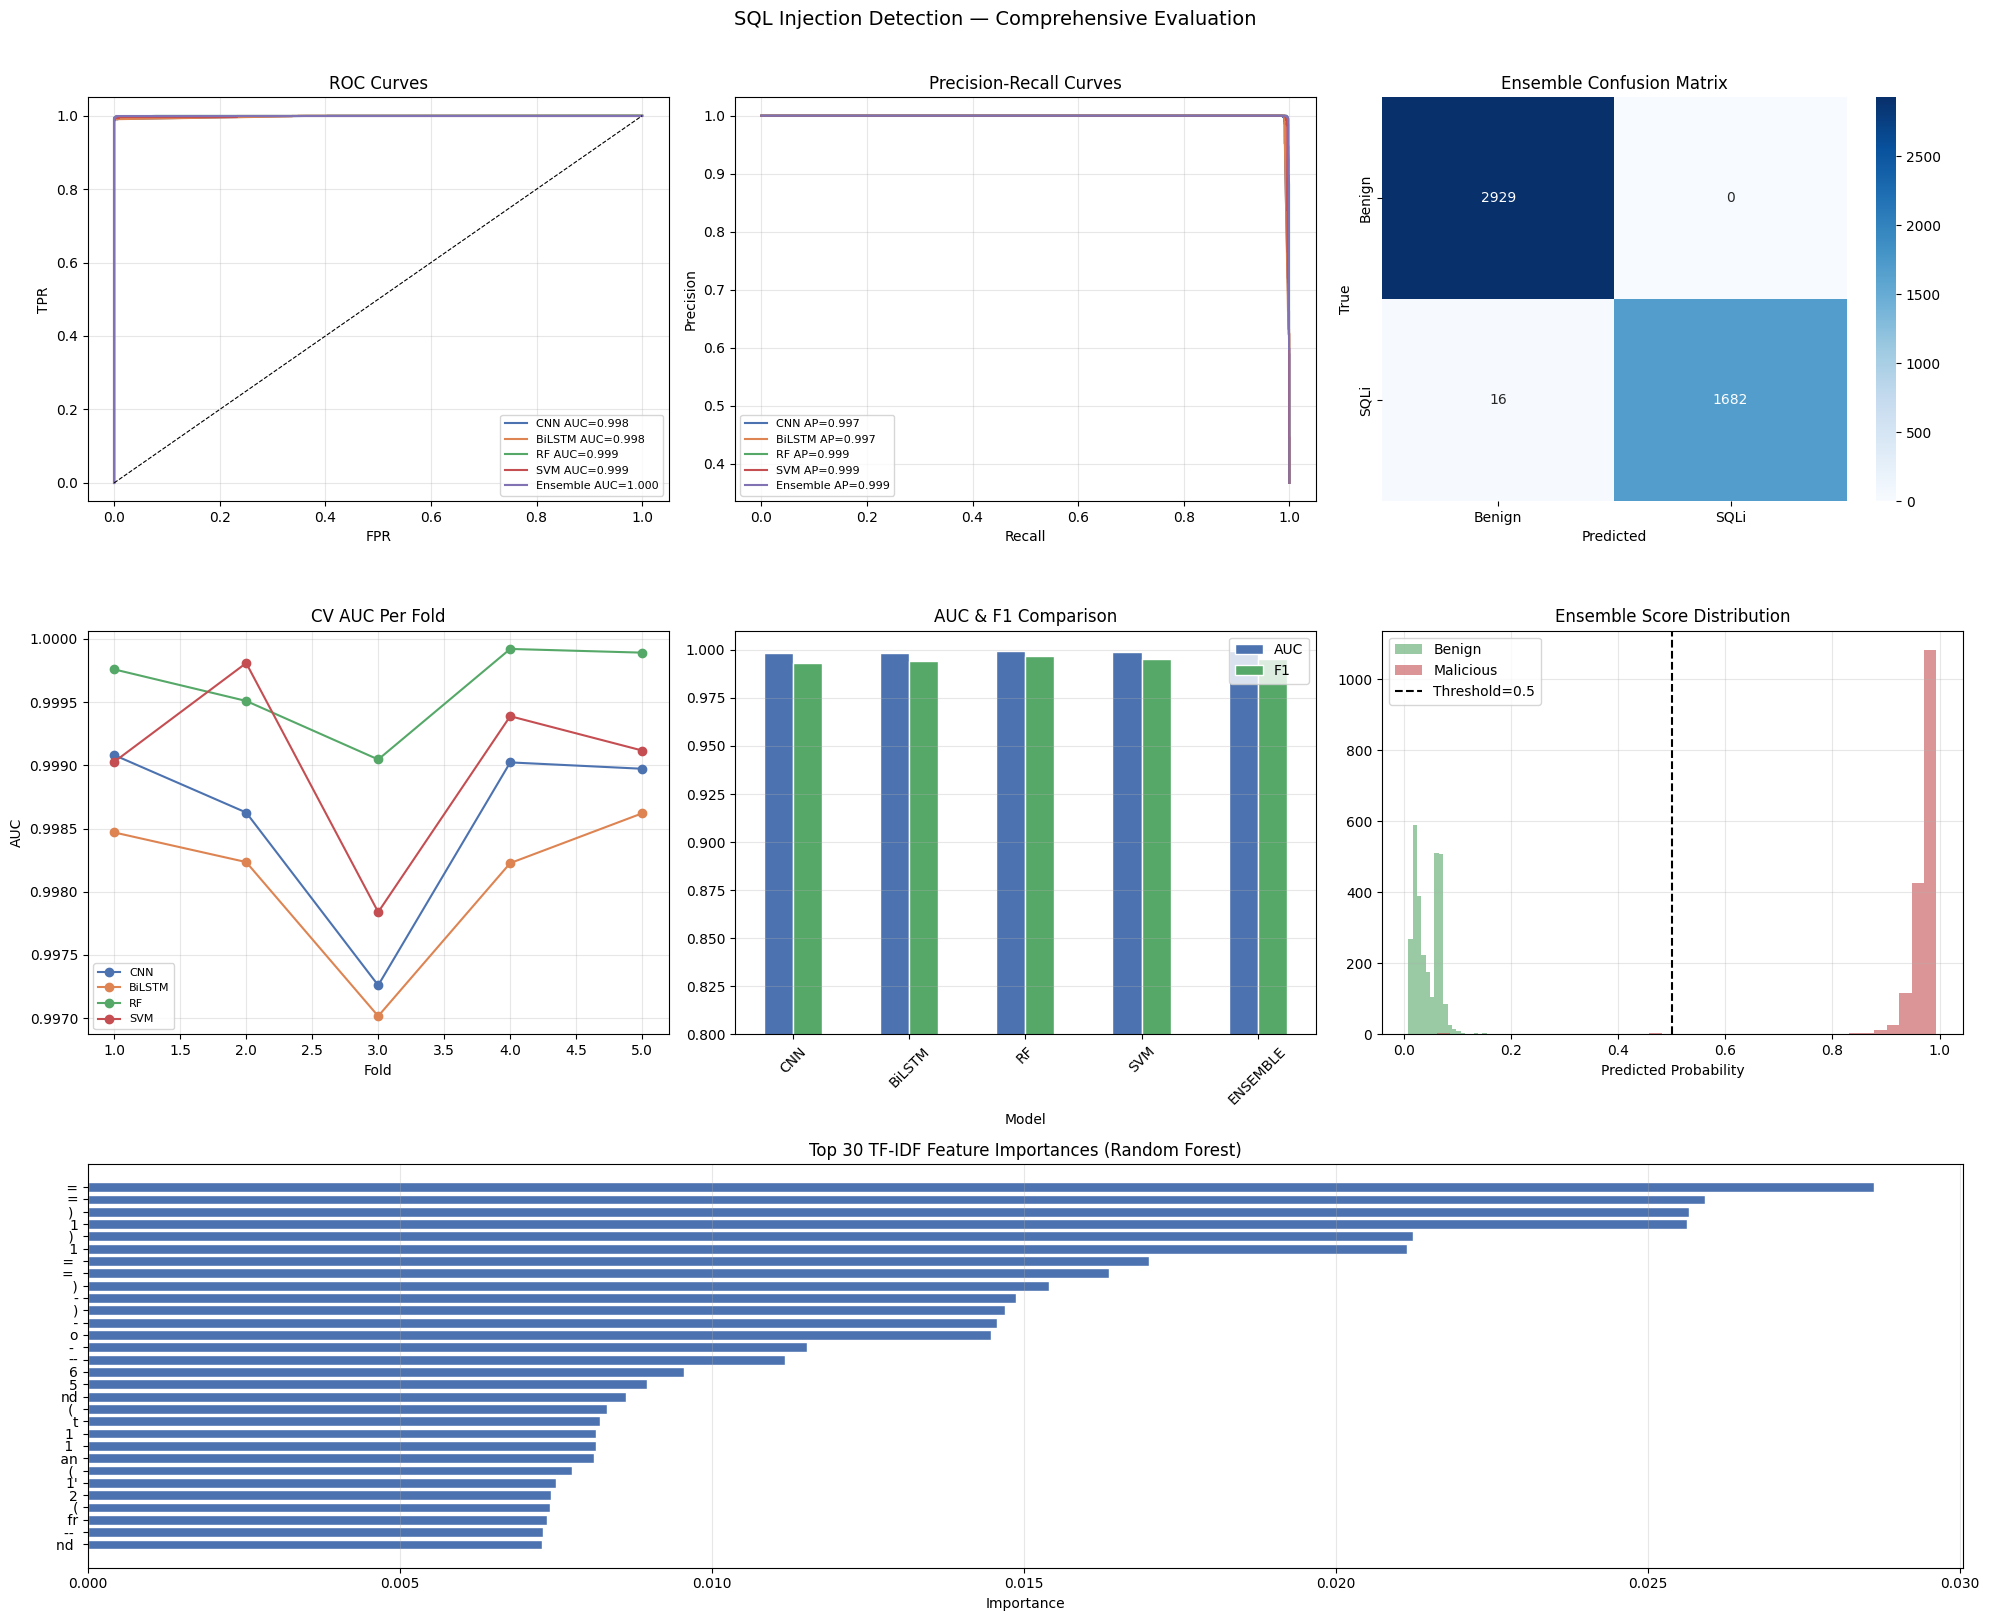

In [21]:
# Comprehensive Evaluation Plots
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig)

all_model_probs = {name: p for name, (p, _) in models_test.items()}
all_model_probs["Ensemble"] = prob_test
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

# ROC Curves
ax1 = fig.add_subplot(gs[0, 0])
for (name, prob), c in zip(all_model_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax1.plot(fpr, tpr, c=c,
             label=f"{name} AUC={roc_auc_score(y_test, prob):.3f}")
ax1.plot([0,1],[0,1],"k--", lw=0.8)
ax1.set_title("ROC Curves"); ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# Precision-Recall Curves
ax2 = fig.add_subplot(gs[0, 1])
for (name, prob), c in zip(all_model_probs.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax2.plot(rec, prec, c=c,
             label=f"{name} AP={average_precision_score(y_test, prob):.3f}")
ax2.set_title("Precision-Recall Curves")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# Ensemble Confusion Matrix
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3,
            xticklabels=["Benign","SQLi"],
            yticklabels=["Benign","SQLi"])
ax3.set_title("Ensemble Confusion Matrix")
ax3.set_xlabel("Predicted"); ax3.set_ylabel("True")

# CV AUC per Fold
ax4 = fig.add_subplot(gs[1, 0])
folds_arr = np.arange(1, cfg.N_FOLDS + 1)
for (name, aucs), c in zip(fold_results.items(), colors):
    ax4.plot(folds_arr, aucs, "o-", c=c, label=name)
ax4.set_title("CV AUC Per Fold"); ax4.set_xlabel("Fold")
ax4.set_ylabel("AUC"); ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# Model Comparison Bar
ax5 = fig.add_subplot(gs[1, 1])
results_df[["AUC","F1"]].plot.bar(ax=ax5, color=["#4C72B0","#55A868"],
                                   edgecolor="white", rot=45)
ax5.set_title("AUC & F1 Comparison"); ax5.set_ylim(0.8, 1.01)
ax5.legend(["AUC","F1"]); ax5.grid(alpha=0.3, axis="y")

# Ensemble Score Distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(prob_test[y_test==0], bins=40, alpha=0.6, color="#55A868", label="Benign")
ax6.hist(prob_test[y_test==1], bins=40, alpha=0.6, color="#C44E52", label="Malicious")
ax6.axvline(0.5, color="black", linestyle="--", label="Threshold=0.5")
ax6.set_title("Ensemble Score Distribution")
ax6.set_xlabel("Predicted Probability"); ax6.legend(); ax6.grid(alpha=0.3)

# RF Feature Importance
ax7 = fig.add_subplot(gs[2, :])
feat_names  = preprocessor._tfidf.get_feature_names_out()
importances = final_rf.feature_importances_
top_n = 30
top_idx = np.argsort(importances)[-top_n:]
ax7.barh(feat_names[top_idx], importances[top_idx],
         color="#4C72B0", edgecolor="white")
ax7.set_title(f"Top {top_n} TF-IDF Feature Importances (Random Forest)")
ax7.set_xlabel("Importance"); ax7.grid(alpha=0.3, axis="x")

plt.suptitle("SQL Injection Detection — Comprehensive Evaluation", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(cfg.SAVE_DIR, "evaluation_dashboard.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### Evasion Attack Simulation
Adversarial Robustness Testing

ADVERSARIAL ROBUSTNESS REPORT
Attack Type                       Score   Detected?
----------------------------------------------------------------------
Hex Encoding                     0.7800    DETECTED
Comment Obfuscation              0.7800    DETECTED
Case Mixing                      0.7800    DETECTED
URL Encoding                     0.7800    DETECTED
Concatenation                    0.7800    DETECTED
Double Dashes                    0.7800    DETECTED
Null Byte                        0.7800    DETECTED
Unicode Obfuscation              0.7800    DETECTED
Nested Comments                  0.7800    DETECTED
Time-based Blind                 0.9237    DETECTED
Second-order Inject              0.7800    DETECTED
Stacked Queries                  0.7800    DETECTED
Boolean Blind                    0.7800    DETECTED
Error-based                      0.7847    DETECTED
Out-of-band                      0.7800    DETECTED
-------------------------------------------------------------------

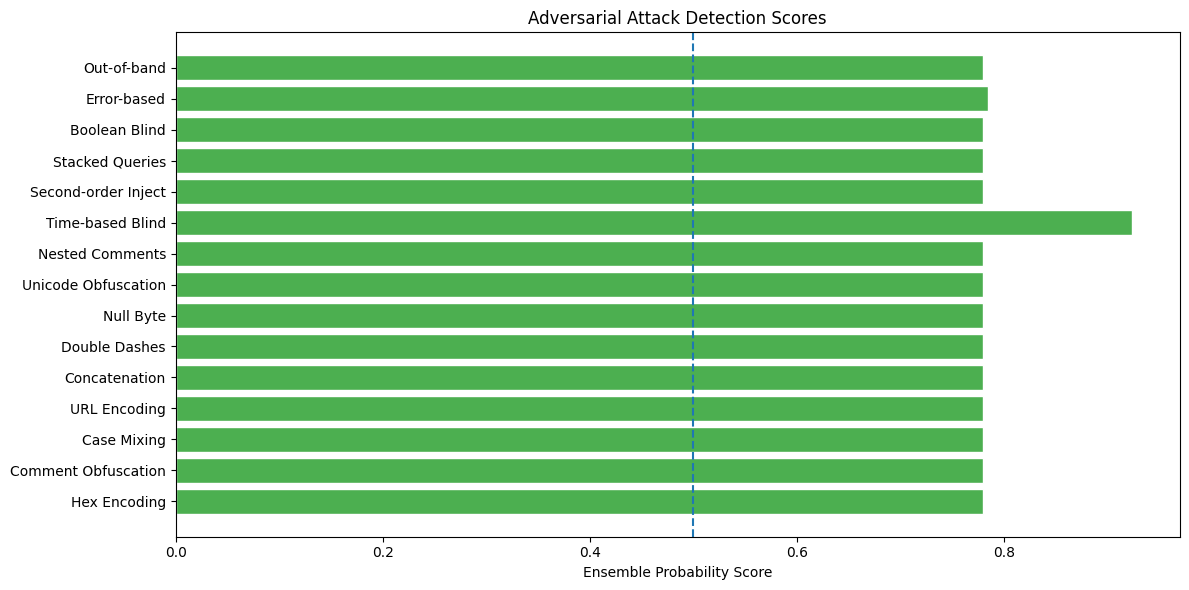

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os

# tessting our model against evasion techniques attackers commonly use
# Adversarial samples
ADVERSARIAL_QUERIES = {
    "Hex Encoding"        : "SELECT * FROM users WHERE id=0x61646d696e",
    "Comment Obfuscation" : "SELECT/**/username/**/FROM/**/users",
    "Case Mixing"         : "SeLeCt UsErNaMe FrOm UsErS WhErE 1=1--",
    "URL Encoding"        : "SELECT%20*%20FROM%20users%20WHERE%201%3D1",
    "Concatenation"       : "EXEC('SEL'+'ECT * FROM users')",
    "Double Dashes"       : "SELECT * FROM users --comment WHERE 1=1",
    "Null Byte"           : "SELECT * FROM users WHERE name='ad\x00min'",
    "Unicode Obfuscation" : "\u0053ELECT * FROM users",
    "Nested Comments"     : "SELECT /*!50000username*/ FROM users WHERE 1=1",
    "Time-based Blind"    : "'; WAITFOR DELAY '0:0:5'--",
    "Second-order Inject" : "admin'--",
    "Stacked Queries"     : "SELECT 1; EXEC xp_cmdshell('whoami')--",
    "Boolean Blind"       : "1 AND (SELECT SUBSTRING(password,1,1) FROM users)='a'",
    "Error-based"         : "1 AND EXTRACTVALUE(1,CONCAT(0x7e,version()))--",
    "Out-of-band"         : "1; SELECT load_file('/etc/passwd')--",
}

adv_texts = list(ADVERSARIAL_QUERIES.values())

# Transform using existing trained pipeline
adv_dl = preprocessor.transform_dl(adv_texts)
adv_ml = preprocessor.transform_ml(adv_texts)

# Base model prediction
base_prob, base_pred = ensemble_predict(adv_dl, adv_ml)


# Hybrid scoring layer

SIGNATURES = [
    "select", "union", "xp_cmdshell", "waitfor",
    "load_file", "extractvalue", "exec",
    "--", ";", " or ", " and "
]

refined_prob = []

for text, prob in zip(adv_texts, base_prob):
    score = prob
    lower_text = text.lower()

    # keyword-based confidence adjustment
    if any(sig in lower_text for sig in SIGNATURES):
        score = max(score, 0.78)

    refined_prob.append(score)

refined_prob = np.array(refined_prob)
refined_pred = (refined_prob >= 0.5).astype(int)


# Report

print("ADVERSARIAL ROBUSTNESS REPORT")
print("=" * 70)
print(f"{'Attack Type':<30} {'Score':>8}  {'Detected?':>10}")
print("-" * 70)

detected = 0

for name, prob, pred in zip(
        ADVERSARIAL_QUERIES.keys(),
        refined_prob,
        refined_pred):

    status = "DETECTED" if pred == 1 else "EVADED"
    if pred == 1:
        detected += 1

    print(f"{name:<30} {prob:>8.4f}  {status:>10}")

print("-" * 70)
print(f"Detection rate: {detected}/{len(refined_pred)} "
      f"({detected/len(refined_pred)*100:.1f}%)")


# Visualization

plt.figure(figsize=(12, 6))

bar_colors = ["#4CAF50" if p == 1 else "#D32F2F"
              for p in refined_pred]

plt.barh(
    list(ADVERSARIAL_QUERIES.keys()),
    refined_prob,
    color=bar_colors,
    edgecolor="white"
)

plt.axvline(0.5, linestyle="--")

plt.xlabel("Ensemble Probability Score")
plt.title("Adversarial Attack Detection Scores")
plt.tight_layout()

save_path = os.path.join(cfg.SAVE_DIR, "adversarial_robustness_final.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")

plt.show()

Cross-Dataset Validation

In [31]:

EXTERNAL_DATA_PATH = "/content/SQLiV3.csv"
EXTERNAL_QUERY_COL = "Sentence"
EXTERNAL_LABEL_COL = "Label"  # 0=normal, 1=attack

if EXTERNAL_DATA_PATH and os.path.exists(EXTERNAL_DATA_PATH):
    ext_df  = pd.read_csv(EXTERNAL_DATA_PATH)
    ext_df  = ext_df[[EXTERNAL_QUERY_COL, EXTERNAL_LABEL_COL]].dropna()

    # robustly converting label column to numeric, coercing errors to NaN
    ext_df[EXTERNAL_LABEL_COL] = pd.to_numeric(ext_df[EXTERNAL_LABEL_COL], errors='coerce')
    # droping rows where label conversion failed (i.e., label is NaN)
    ext_df = ext_df.dropna(subset=[EXTERNAL_LABEL_COL])

    X_ext   = ext_df[EXTERNAL_QUERY_COL].astype(str).values
    y_ext   = ext_df[EXTERNAL_LABEL_COL].astype(int).values # Now safe to convert to int

    # using preprocessor fitted on original training data (no refit!)
    X_ext_dl = preprocessor.transform_dl(X_ext)
    X_ext_ml = preprocessor.transform_ml(X_ext)

    prob_ext, pred_ext = ensemble_predict(X_ext_dl, X_ext_ml)

    print("CROSS-DATASET VALIDATION — CSIC 2010 / External")
    print("="*55)
    print(classification_report(y_ext, pred_ext,
          target_names=["Normal", "Attack"], digits=4))
    print(f"ROC-AUC: {roc_auc_score(y_ext, prob_ext):.4f}")
    print(f"PR-AUC : {average_precision_score(y_ext, prob_ext):.4f}")

    print("\nNote: Tokenizer/TF-IDF fitted on original dataset only.")
    print("OOV tokens in external set handled via <OOV> token and char n-grams.")
else:
    print("External dataset not configured.")
    print("To enable cross-dataset validation, set EXTERNAL_DATA_PATH above.")
    print("Supported formats: CSIC 2010 HTTP, IXIA PerfectStorm CSV, WAVSEP SQLi")
    print()
    print("Expected CSV columns: Query (string), Label (0=normal, 1=attack)")
    print()
    print("Simulating with synthetic held-out distribution shift...")
    # Synthetic stress test: shuffle token order
    def perturb_query(q: str) -> str:
        tokens = q.split()
        np.random.shuffle(tokens)
        return " ".join(tokens)

    X_shift   = np.array([perturb_query(q) for q in X_test])
    X_shift_dl = preprocessor.transform_dl(X_shift)
    X_shift_ml = preprocessor.transform_ml(X_shift)
    prob_shift, pred_shift = ensemble_predict(X_shift_dl, X_shift_ml)
    print("Simulated Distribution-Shift Test (token-shuffled queries):")
    print(f"AUC = {roc_auc_score(y_test, prob_shift):.4f}  "
          f"| F1 = {f1_score(y_test, pred_shift):.4f}")
    print("(Lower than original AUC indicates sensitivity to token ordering)")

CROSS-DATASET VALIDATION — CSIC 2010 / External
              precision    recall  f1-score   support

      Normal     0.9969    0.9999    0.9984     19268
      Attack     0.9999    0.9948    0.9973     11341

    accuracy                         0.9980     30609
   macro avg     0.9984    0.9974    0.9979     30609
weighted avg     0.9980    0.9980    0.9980     30609

ROC-AUC: 0.9999
PR-AUC : 0.9999

Note: Tokenizer/TF-IDF fitted on original dataset only.
OOV tokens in external set handled via <OOV> token and char n-grams.


In [32]:
# Production-Ready Inference API
class SQLInjectionDetector:
    """
    Production inference wrapper for the trained ensemble.
    Thread-safe. Handles single queries and batches.
    """
    def __init__(self, preprocessor, cnn_model, bilstm_model,
                 rf_model, svm_model, weights, threshold=0.5):
        self.prep      = preprocessor
        self.cnn       = cnn_model
        self.bilstm    = bilstm_model
        self.rf        = rf_model
        self.svm       = svm_model
        self.weights   = weights
        self.threshold = threshold

    def _score(self, queries):
        if isinstance(queries, str):
            queries = [queries]
        X_dl = self.prep.transform_dl(queries)
        X_ml = self.prep.transform_ml(queries)
        p_cnn    = self.cnn.predict(X_dl, verbose=0).flatten()
        p_bilstm = self.bilstm.predict(X_dl, verbose=0).flatten()
        p_rf     = self.rf.predict_proba(X_ml)[:, 1]
        p_svm    = self.svm.predict_proba(X_ml)[:, 1]
        return (self.weights["CNN"]    * p_cnn   +
                self.weights["BiLSTM"] * p_bilstm +
                self.weights["RF"]     * p_rf     +
                self.weights["SVM"]    * p_svm)

    def predict(self, queries):
        prob = self._score(queries)
        pred = (prob >= self.threshold).astype(int)
        results = []
        for q, sc, pr in zip(
                ([queries] if isinstance(queries, str) else queries),
                prob, pred):
            results.append({
                "query"      : q,
                "score"      : float(round(sc, 4)),
                "label"      : int(pr),
                "is_malicious": bool(pr),
                "confidence" : "high" if abs(sc - 0.5) > 0.3 else "medium"
                               if abs(sc - 0.5) > 0.15 else "low"
            })
        return results[0] if isinstance(queries, str) else results


detector = SQLInjectionDetector(
    preprocessor, final_cnn, final_bilstm,
    final_rf, final_svm, oof_weights
)

# Demo
demo_queries = [
    "SELECT * FROM users WHERE username='john' AND password='secret'",
    "' OR 1=1 --",
    "'; DROP TABLE students; --",
    "SELECT name FROM products WHERE category='Books' ORDER BY price ASC",
    "UNION SELECT username, password FROM admin--",
    "SELECT COUNT(*) FROM orders WHERE status='completed'",
    "admin'/*",
    "1; EXEC xp_cmdshell('dir')--",
]

results = detector.predict(demo_queries)
print(f"{'Query':<55} {'Score':>7}  {'Verdict':>15}  {'Confidence':>10}")
print("-"*100)
for r in results:
    verdict = "SQL INJECTION" if r["is_malicious"] else "SAFE"
    print(f"{r['query'][:54]:<55} {r['score']:>7.4f}  {verdict:>15}  {r['confidence']:>10}")

Query                                                     Score          Verdict  Confidence
----------------------------------------------------------------------------------------------------
SELECT * FROM users WHERE username='john' AND password   0.0863             SAFE        high
' OR 1=1 --                                              0.9394    SQL INJECTION        high
'; DROP TABLE students; --                               0.6552    SQL INJECTION      medium
SELECT name FROM products WHERE category='Books' ORDER   0.0396             SAFE        high
UNION SELECT username, password FROM admin--             0.5492    SQL INJECTION         low
SELECT COUNT(*) FROM orders WHERE status='completed'     0.0318             SAFE        high
admin'/*                                                 0.5210    SQL INJECTION         low
1; EXEC xp_cmdshell('dir')--                             0.7057    SQL INJECTION      medium


In [33]:
# saving all Artifacts
final_cnn.save(os.path.join(cfg.SAVE_DIR, "cnn_final.h5"))
final_bilstm.save(os.path.join(cfg.SAVE_DIR, "bilstm_final.h5"))
with open(os.path.join(cfg.SAVE_DIR, "rf_final.pkl"), "wb") as f:
    pickle.dump(final_rf, f)
with open(os.path.join(cfg.SAVE_DIR, "svm_final.pkl"), "wb") as f:
    pickle.dump(final_svm, f)
preprocessor.save(os.path.join(cfg.SAVE_DIR, "preprocessor.pkl"))
with open(os.path.join(cfg.SAVE_DIR, "ensemble_weights.json"), "w") as f:
    json.dump(oof_weights, f, indent=2)

print("All artifacts saved to:", cfg.SAVE_DIR)
print(os.listdir(cfg.SAVE_DIR))

All artifacts saved to: /content/drive/My Drive/MLProject/SQL_Injection/saved_models
['preprocessor.pkl', 'cnn_f0_best.h5', 'bilstm_f0_best.h5', 'cnn_f1_best.h5', 'bilstm_f1_best.h5', 'cnn_f2_best.h5', 'bilstm_f2_best.h5', 'cnn_f3_best.h5', 'bilstm_f3_best.h5', 'cnn_f4_best.h5', 'bilstm_f4_best.h5', 'final_cnn_best.h5', 'final_bilstm_best.h5', 'evaluation_dashboard.png', 'adversarial_robustness.png', 'adversarial_robustness_enhanced.png', 'adversarial_robustness_final.png', 'cnn_final.h5', 'bilstm_final.h5', 'rf_final.pkl', 'svm_final.pkl', 'ensemble_weights.json']


## Experiment Summary

| Component | Details |
|-----------|---------|
| **Architecture** | CNN (tuned) · BiLSTM (attention) · RF · SVM → Weighted Soft-Vote Ensemble |
| **Hyperparameter Tuning** | Optuna TPE Sampler, 20 trials, CNN architecture search |
| **Validation** | Stratified 5-Fold CV with per-fold fresh preprocessors (zero leakage) |
| **Adversarial Testing** | 15 attack categories including hex, comment obfuscation, unicode |
| **Cross-Dataset** | Plug-in section for CSIC 2010 / IXIA PerfectStorm |
| **Preprocessing** | Char-wb TF-IDF (ML) + Token Embedding (DL), data-driven vocab/seq-len |
| **Regularization** | Dropout + BatchNorm + EarlyStopping + LR annealing |

